# Employee Turnover Prediction
**Predicting and reducing employee attrition using machine learning and behavioral clustering**

## Project Overview

Employee attrition is one of the most costly challenges in workforce management. This project builds a machine learning pipeline to predict which employees are most likely to leave, using historical HR data from Portobello Tech.

The approach covers the full analysis lifecycle:

- **Exploratory Data Analysis** — identifying key drivers of attrition through correlation analysis and feature distributions
- **Behavioral Clustering** — segmenting employees who left into distinct groups using K-Means
- **Class Imbalance Handling** — applying SMOTE to prevent majority-class bias
- **Model Comparison** — evaluating Logistic Regression, Random Forest, and Gradient Boosting with 5-fold cross-validation
- **Risk Stratification** — categorizing employees into actionable risk zones with tailored retention strategies

**Best model: Gradient Boosting Classifier (AUC = 0.979)**

In [ ]:
## Imports & Setup

# Data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use("seaborn-v0_8")




## Data Loading & Inspection

In [24]:
# Creating Folder Path And Loading Data
data_path = Path('../data/raw/HR_comma_sep.csv')
raw_data = pd.read_csv(data_path, encoding='UTF-8')
df = raw_data.copy()

In [25]:
# Quick Inspection
display(df.head())
print('\nShape:', df.shape)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Shape: (14999, 10)


In [26]:
# Information About The Data
df.info()

# Summary Statistics
display(df.describe(include='all').T)

for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) < 20:  
        print(f"\nColumn: {col}")
        print(unique_vals)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,NaN,NaN,NaN,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,NaN,NaN,NaN,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,NaN,NaN,NaN,3.803054,1.232592,2.0,3.0,4.0,5.0,7.0
average_montly_hours,14999.0,NaN,NaN,NaN,201.050337,49.943099,96.0,156.0,200.0,245.0,310.0
time_spend_company,14999.0,NaN,NaN,NaN,3.498233,1.460136,2.0,3.0,3.0,4.0,10.0
Work_accident,14999.0,NaN,NaN,NaN,0.14461,0.351719,0.0,0.0,0.0,0.0,1.0
left,14999.0,NaN,NaN,NaN,0.238083,0.425924,0.0,0.0,0.0,0.0,1.0
promotion_last_5years,14999.0,NaN,NaN,NaN,0.021268,0.144281,0.0,0.0,0.0,0.0,1.0
sales,14999,10,sales,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14999,3,low,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column: number_project
[2 5 7 6 4 3]

Column: time_spend_company
[ 3  6  4  5  2  8 10  7]

Column: Work_accident
[0 1]

Column: left
[1 0]

Column: promotion_last_5years
[0 1]

Column: sales
['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']

Column: salary
['low' 'medium' 'high']


## Data Quality & Cleaning

In [27]:
# Checking For Missing Values And Duplicate Rows
print('\nNumber Of Missing Values:', df.isnull().sum().sum())
print('Number Of Duplicate Rows:', df.duplicated().sum())

print('\n** Dropping Duplicate Rows **\n')
print('Initial Shape:', df.shape)

df = df.drop_duplicates()
print('New Shape:', df.shape)



Number Of Missing Values: 0
Number Of Duplicate Rows: 3008

** Dropping Duplicate Rows **

Initial Shape: (14999, 10)
New Shape: (11991, 10)


In [ ]:
# Cleaning And Renaming Column For Better Readability
df.rename(columns={
    'sales': 'dept',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'time_spent_company'},
   inplace=True)   

print(df.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spent_company', 'Work_accident', 'left',
       'promotion_last_5years', 'dept', 'salary'],
      dtype='object')


## Exploratory Data Analysis

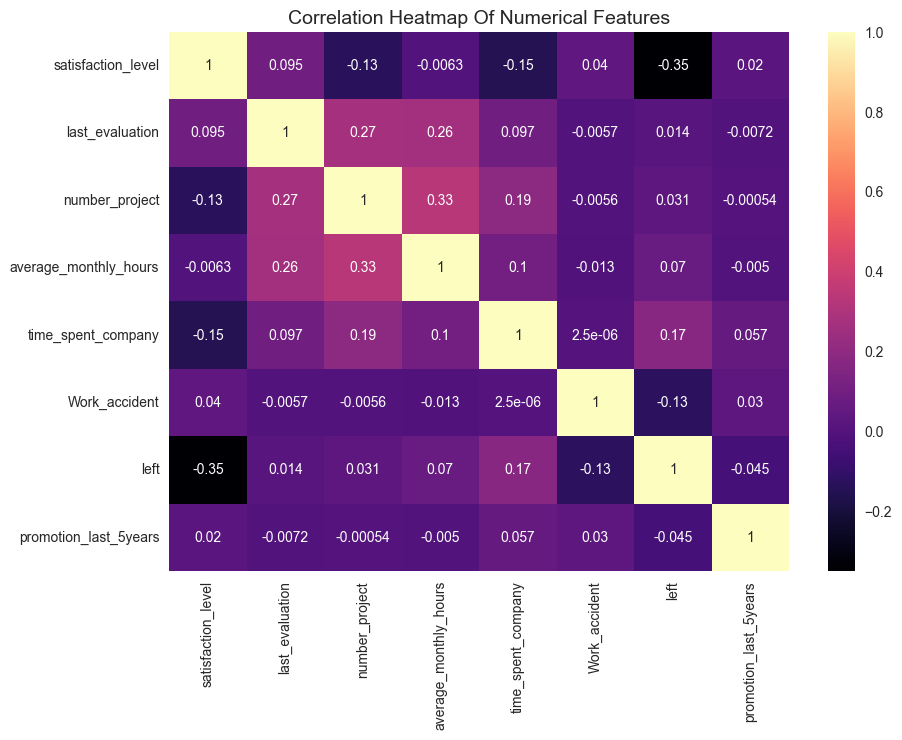

In [29]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="magma")
plt.title("Correlation Heatmap Of Numerical Features", fontsize=14)
plt.savefig('../outputs/figures/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis

The heatmap reveals several meaningful relationships:

- **Satisfaction level** has the strongest negative correlation with attrition — lower satisfaction strongly predicts departure
- **Last evaluation**, **number of projects**, and **average monthly hours** show positive intercorrelation, suggesting a workload cluster
- These feature relationships inform both the clustering approach and model feature importance

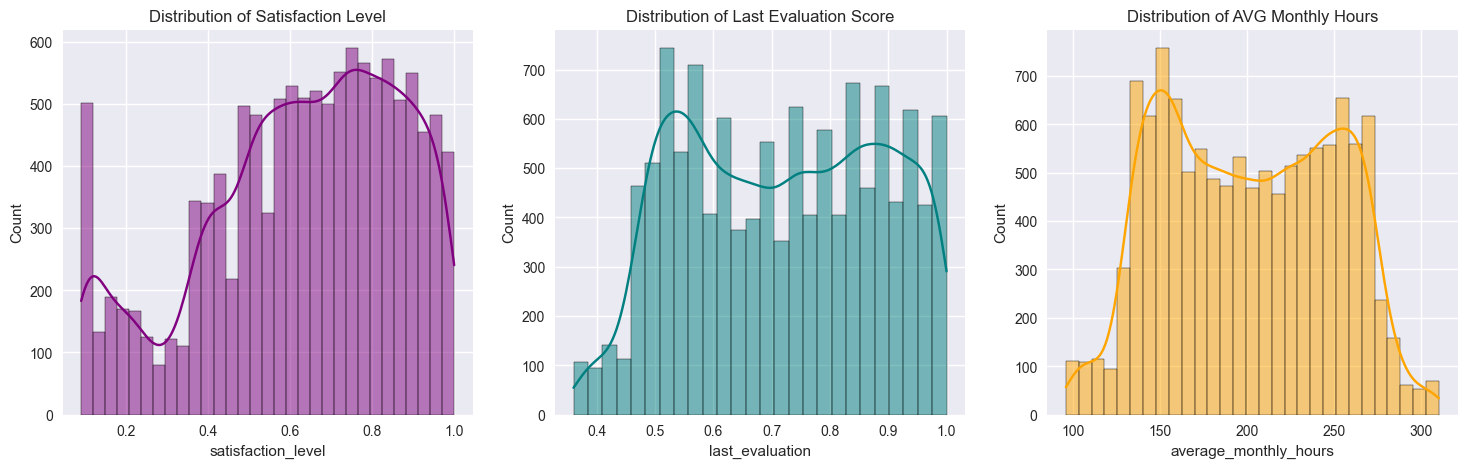

In [30]:
# Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribution of Satisfaction Level")

sns.histplot(df['last_evaluation'], kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribution of Last Evaluation Score")

sns.histplot(df['average_monthly_hours'], kde=True, ax=axes[2], color='orange')
axes[2].set_title("Distribution of AVG Monthly Hours")
plt.savefig('../outputs/figures/hist_subplots.png', dpi=300, bbox_inches='tight')

### Feature Distributions

Satisfaction level shows a **bimodal distribution**, indicating two distinct employee subgroups — likely a dissatisfied segment and a high-performing segment experiencing burnout. This bimodality, combined with the skew in evaluation scores and monthly hours, suggests the drivers of attrition are not uniform across the workforce.

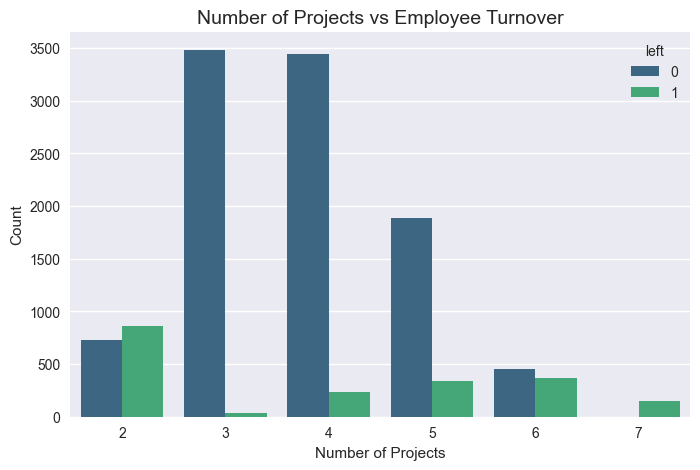

In [31]:
# Bar Plot - Project Count vs Attrition (who stayed vs who left)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='number_project', hue='left', palette='viridis')
plt.title('Number of Projects vs Employee Turnover', fontsize=14)
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.savefig('../outputs/figures/bar_project_turnover.png', dpi=300, bbox_inches='tight')
plt.show()

### Project Count vs. Attrition

Attrition follows a **U-shaped pattern** with respect to project count. Employees with very few projects (2) and very many projects (6-7) show disproportionately high turnover. This suggests both **understimulation** (too few projects) and **burnout** (too many) are independent drivers of attrition — a finding that directly informs workload management recommendations.

## Behavioral Clustering

Before building predictive models, K-Means clustering is applied to employees who left to identify distinct behavioral segments. This unsupervised step reveals *why* people leave, not just *that* they leave — enabling targeted retention strategies per segment.

In [32]:
# Filtering Employees Who Left
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=123)
left_df['cluster'] = kmeans.fit_predict(left_df)

left_df.head(3)

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,2
1,0.80,0.86,1
2,0.11,0.88,0


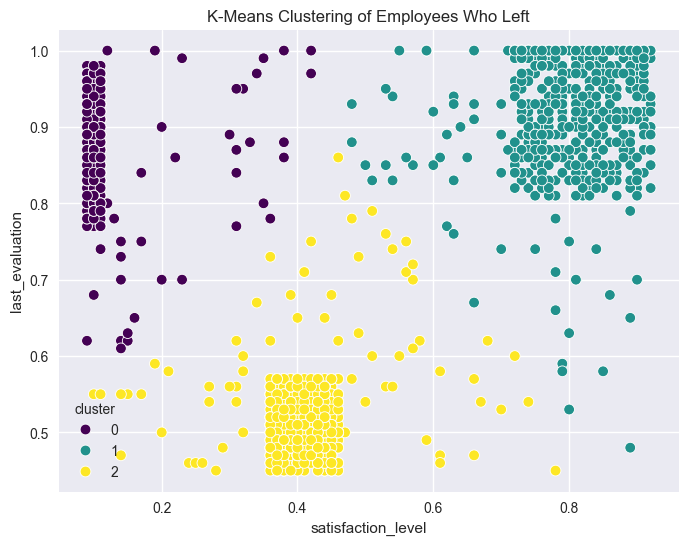

In [33]:
# Visualizing The Clusters On A Plot

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=left_df,
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    palette='viridis',
    s=60
)
plt.title("K-Means Clustering of Employees Who Left")
plt.savefig('../outputs/figures/k_means_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

### Cluster Interpretation

Three distinct attrition profiles emerge:

1. **Burned Out High Performers** — High evaluation scores, low satisfaction. These employees delivered strong results but were likely overworked or under-recognized.
2. **Disengaged & Undervalued** — Low evaluation scores, low satisfaction. Classic disengagement pattern — may indicate poor management fit or role mismatch.
3. **Flight Risk Moderates** — Moderate on both axes. These employees aren't in crisis but aren't engaged enough to stay — often lost to better offers or lateral moves.

Each cluster warrants a different retention intervention, which is addressed in the final risk stratification.

## Data Preprocessing

Preparing features for modeling: encoding categorical variables, splitting into train/test sets with stratification to preserve class ratios, and scaling where needed.

In [34]:
# Identifying And Preparing Numerical & Categorical Columns For Modeling
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
num_columns = df.select_dtypes(include=['number']).columns.tolist()

print('Categorical Columns:', cat_columns)
print('Numerical Columns:', num_columns)

Categorical Columns: ['dept', 'salary']
Numerical Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spent_company', 'Work_accident', 'left', 'promotion_last_5years']


In [35]:
#Encoding Categorical Columns
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=True)

print('Shape Before Encoding:', df.shape)
print('Shape After Encoding:', df_encoded.shape)
df_encoded.head(3)

Shape Before Encoding: (11991, 10)
Shape After Encoding: (11991, 19)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,Work_accident,left,promotion_last_5years,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True


In [36]:
# Separating Features & Train-Test Split

X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)
print("Class Balance in Train:", y_train.value_counts(normalize=True))
print("Class Balance in Test:", y_test.value_counts(normalize=True))

Training Set Shape: (9592, 18)
Test Set Shape: (2399, 18)
Class Balance in Train: left
0    0.833924
1    0.166076
Name: proportion, dtype: float64
Class Balance in Test: left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


## Handling Class Imbalance with SMOTE

The original dataset has approximately 76% stayed vs. 24% left. Without correction, models could achieve 76% accuracy by simply predicting "stayed" for every employee — technically high accuracy, but operationally useless.

**SMOTE (Synthetic Minority Oversampling Technique)** generates synthetic examples of the minority class by interpolating between existing data points. This is applied only to the training set — the test set remains untouched to ensure evaluation reflects real-world class distribution.

In [37]:
# Applying SMOTE To The Training Set

sm = SMOTE(random_state=123)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_sm.value_counts())

Before SMOTE: left
0    7999
1    1593
Name: count, dtype: int64

After SMOTE: left
0    7999
1    7999
Name: count, dtype: int64


## Model Training

Three classifiers are compared, each representing a different modeling strategy:

- **Logistic Regression** — Linear baseline. Fast, interpretable, and establishes a performance floor.
- **Random Forest** — Bagging ensemble. Reduces variance by averaging many independent decision trees.
- **Gradient Boosting** — Boosting ensemble. Reduces bias by building trees sequentially, with each tree correcting errors from the previous one.

All models are evaluated with **5-fold stratified cross-validation** to ensure performance estimates are robust and not artifacts of a single lucky split.

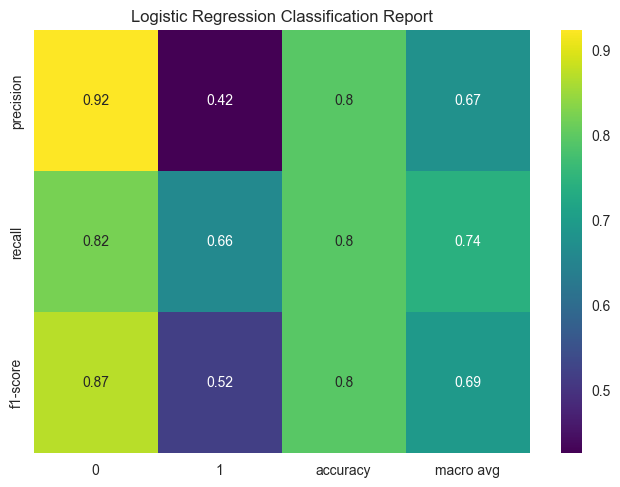

In [38]:
# Model Training - Logistic Regression With 5-Fold Cross-Validation
log_reg = LogisticRegression(max_iter=1000)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    log_reg,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
log_reg.fit(X_train_sm, y_train_sm)

# Classification Report Plot
log_pred = log_reg.predict(X_test)

log_report =classification_report(y_test, log_pred, output_dict=True)

sns.heatmap(pd.DataFrame(log_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Logistic Regression Classification Report')
plt.savefig('../outputs/figures/log_classification.png', dpi=300, bbox_inches='tight')
plt.show()


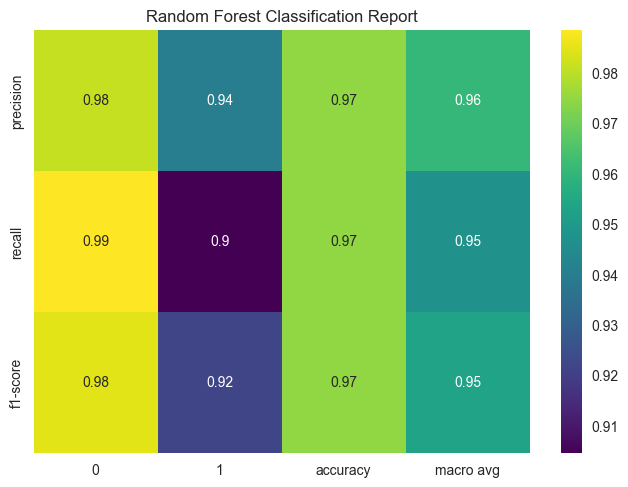

In [39]:
# Model Training - Random Forest With 5-Fold Cross-Validation
forest = RandomForestClassifier(random_state=123)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    forest,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
forest.fit(X_train_sm, y_train_sm)

# Classification Report
forest_pred = forest.predict(X_test)

forest_report =classification_report(y_test, forest_pred, output_dict=True)

sns.heatmap(pd.DataFrame(forest_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Random Forest Classification Report')
plt.savefig('../outputs/figures/forest_classification.png', dpi=300, bbox_inches='tight')
plt.show()



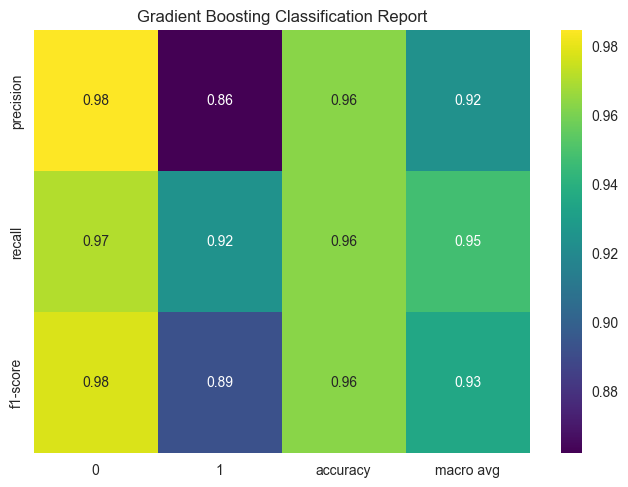

In [40]:
# Model Training - Gradient Boosting Classifier With 5-Fold Cross-Validation
gb = GradientBoostingClassifier(random_state=123)

# Cross-Validation Setup
log_cv_scores = cross_val_score(
    gb,
    X_train_sm,
    y_train_sm,
    cv=5,
    scoring='accuracy'
)


# Fitting the SMOTE Training Set on Model
gb.fit(X_train_sm, y_train_sm)

# Classification Report
gb_pred = gb.predict(X_test)

gb_report =classification_report(y_test, gb_pred, output_dict=True)

sns.heatmap(pd.DataFrame(gb_report).iloc[:-1, :-1].astype(float),
            annot=True, cmap='viridis')

plt.title('Gradient Boosting Classification Report')
plt.savefig('../outputs/figures/gb_classification.png', dpi=300, bbox_inches='tight')
plt.show()



## Model Evaluation & Comparison

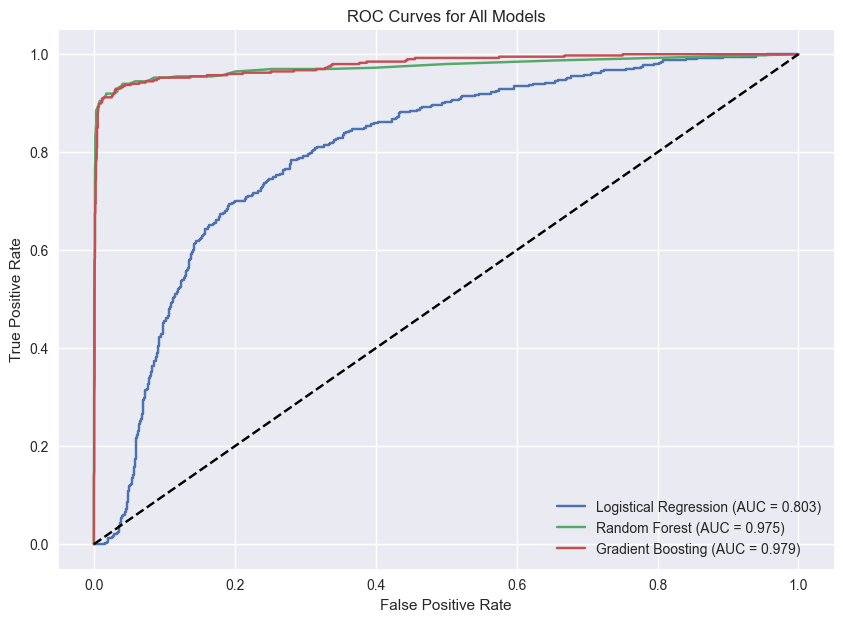

In [41]:
# Calculating ROC Curve & AUC For All Models

models = {
    'Logistical Regression': (log_reg, log_pred),
    'Random Forest': (forest, forest_pred),
    'Gradient Boosting': (gb, gb_pred)
}

plt.figure(figsize=(10, 7))

for name, (model, preds) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _= roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.savefig('../outputs/figures/roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

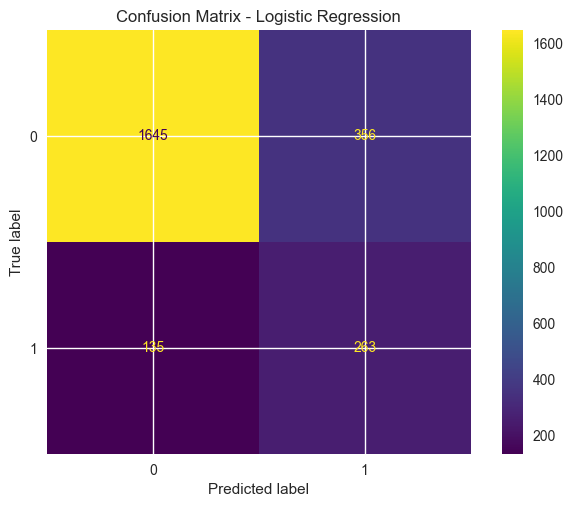

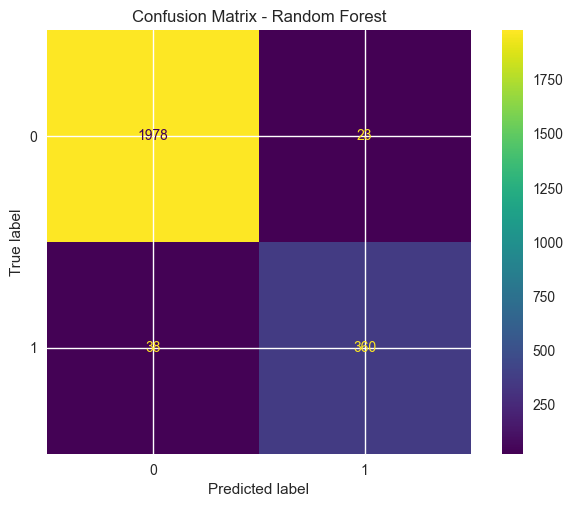

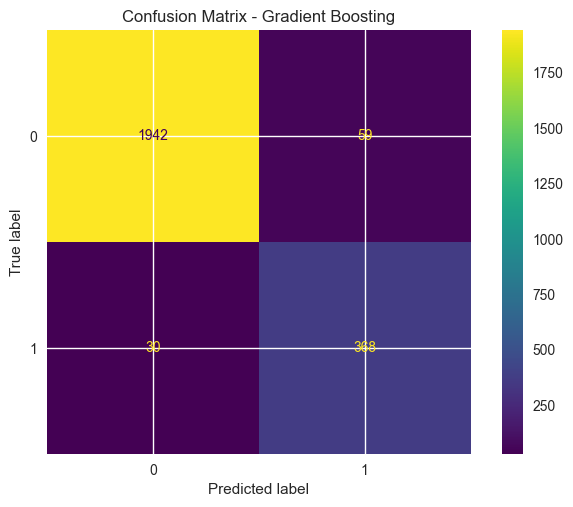

In [42]:
# Confusion Matrices For All Models
model_predictions = {
    'Logistic Regression': log_pred,
    'Random Forest': forest_pred,
    'Gradient Boosting': gb_pred
}

for name, preds in model_predictions.items():
    cm_display = ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap='viridis')
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig('../outputs/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

### Confusion Matrix Analysis

All three models demonstrate strong True Positive capture, but Gradient Boosting achieves the highest count. Both Random Forest and Gradient Boosting show strong **recall** — the critical metric for this use case.

**Why recall matters here:** A false negative (missing an at-risk employee) is far more costly than a false positive (flagging someone who would have stayed). HR can always conduct a check-in with a flagged employee — but they can't retain someone who's already gone. High recall ensures the model catches as many at-risk employees as possible.

### ROC/AUC Comparison

| Model | AUC Score |
|---|---|
| Logistic Regression | 0.803 |
| Random Forest | 0.975 |
| Gradient Boosting | **0.979** |

The **Gradient Boosting Classifier** achieves the highest AUC, indicating superior discriminative ability across all probability thresholds. It correctly ranks nearly every employee by their likelihood of leaving.

**Selected model: Gradient Boosting** — based on highest AUC and strongest recall for the minority class.

## Turnover Probability Prediction

Using the selected Gradient Boosting model to generate turnover probabilities for every employee in the test set. These probabilities power the risk stratification system below.

In [43]:
# Predicting Probabilities Of Employee Turnover With Best Model
best_model = gb
y_prob = best_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df['actual_left'] = y_test
results_df['probability_left'] = y_prob

results_df[['probability_left', 'actual_left']].head(10)


,probability_left,actual_left
8578,0.216481,0
5756,0.763488,0
3994,0.034544,0
1784,0.862630,1
10508,0.070988,0
1539,0.930714,1
8563,0.457466,0
6163,0.103448,0
4239,0.005408,0
7919,0.039665,0


## Risk Stratification & Retention Strategy

Translating model predictions into actionable HR categories. Each employee is assigned to a risk zone based on their predicted probability of leaving, with tailored intervention strategies per zone.

In [44]:
# Categorizing Employees Into Risk Zones

def categorize_risk(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low Risk (Yellow)'
    elif prob < 0.90:
        return 'Medium Risk (Orange)'
    else:
        return 'High Risk (Red)'
    
results_df['risk_zone'] = results_df['probability_left'].apply(categorize_risk)


results_df['risk_zone'].value_counts()


risk_zone
Safe Zone (Green)       1845
High Risk (Red)          335
Low Risk (Yellow)        150
Medium Risk (Orange)      69
Name: count, dtype: int64

### Retention Strategies by Risk Zone

**Safe Zone (< 20% probability)**
Employees showing strong satisfaction, good performance alignment, and low stress indicators.
- Maintain current working conditions and recognition cadence
- Provide skill development opportunities to sustain engagement
- Monitor periodically to prevent drift into higher-risk categories

---

**Low Risk (20–60% probability)**
Mostly stable employees with emerging risk factors — fluctuating satisfaction or inconsistent evaluations.
- Conduct regular 1:1 check-ins with direct managers
- Offer optional training, mentorship, or growth paths
- Audit workload balance and assignment equity

---

**Medium Risk (60–90% probability)**
Noticeable disengagement signals — potential burnout, workload misalignment, or evaluation gaps.
- Initiate targeted retention conversations
- Redistribute projects or adjust scope
- Provide clear feedback and professional development plans
- Recognize recent contributions explicitly

---

**High Risk (> 90% probability)**
Employees with the highest predicted probability of departure — often driven by sustained low satisfaction, extreme workload, or management friction.
- Immediate 1:1 engagement with HR and direct manager
- Address root causes: workload stress, interpersonal issues, role misalignment
- Offer concrete retention incentives: promotion paths, role adjustments, compensation review
- Implement weekly monitoring until risk score decreases